In [ ]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import time


### Scrape

In [ ]:
all_crypto_data = []
pages_to_fetch = 5  # To ensure more than 1000 rows (5 * 250 = 1250)

print("Starting data extraction... Please wait and do not interrupt the code.")

for page in range(1, pages_to_fetch + 1):
    url = "https://api.coingecko.com/api/v3/coins/markets"
    params = {
        'vs_currency': 'usd',
        'order': 'market_cap_desc',
        'per_page': 250,
        'page': page,
        'sparkline': 'false'
    }
    
    success = False
    attempts = 0
    
    while not success and attempts < 3:  # Try up to 3 times per page
        try:
            response = requests.get(url, params=params)
            
            if response.status_code == 200:
                data = response.json()
                all_crypto_data.extend(data)
                print(f" Page {page}: Retrieved {len(data)} coins.")
                success = True
            
            elif response.status_code == 429:
                print(f" Page {page}: Rate limit reached. Waiting 60 seconds...")
                time.sleep(65)  # Slightly longer wait
                attempts += 1
            
            else:
                print(f" Error on page {page}: Status code {response.status_code}")
                break
                
        except Exception as e:
            print(f"Unexpected error: {e}")
            break
            
    # Normal delay between pages to avoid being blocked
    if success:
        print("Short break (5 seconds)...")
        time.sleep(5)

# Final saving
if len(all_crypto_data) > 0:
    df = pd.DataFrame(all_crypto_data)
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
    filename = f"crypto_data_raw_{current_time}.csv"
    df.to_csv(filename, index=False)
    
    print(f"\n Success! Data saved as: {filename}")
    print(f"Dataset shape: {df.shape}")
else:
    print("\n Failed to retrieve data. Try changing your internet connection or try again later.")
import pandas as pd
import os

# 1. Search for the file that starts with "crypto_data_raw"
# (This helps so you don't need to type the date & time manually)
files = [f for f in os.listdir() if f.startswith('crypto_data_raw') and f.endswith('.csv')]
files.sort()  # Sort files so the latest file is last

if files:
    latest_file = files[-1]  # Select the most recently generated file
    print(f" Opening file: {latest_file}")
    
    # 2. Read the file
    df = pd.read_csv(latest_file)
    
    # 3. Display the first 5 rows
    display(df.head())
    
    print(f"\n Number of rows: {df.shape[0]}")
    print(f" Number of columns: {df.shape[1]}")
else:
    print(" No file found starting with 'crypto_data_raw'. Make sure you successfully ran step 1.")


Starting data extraction... Please wait and do not interrupt the code.
 Page 1: Retrieved 250 coins.
Short break (20 seconds)...
 Page 2: Retrieved 250 coins.
Short break (20 seconds)...
 Page 3: Retrieved 250 coins.
Short break (20 seconds)...
 Page 4: Retrieved 250 coins.
Short break (20 seconds)...
 Page 5: Retrieved 250 coins.
Short break (20 seconds)...

 Success! Data saved as: crypto_data_raw_2025-12-04_15-14.csv
Dataset shape: (1250, 26)
 Opening file: crypto_data_raw_2025-12-04_15-14.csv


,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,92602.00,1848337735113,1,1.848338e+12,7.390020e+10,94001.00,...,1.995748e+07,2.100000e+07,126080.00,-26.25007,2025-10-06T18:57:42.558Z,67.810000,1.370261e+05,2013-07-06T00:00:00.000Z,NaN,2025-12-04T13:10:44.954Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,3162.09,381674998858,2,3.816750e+11,3.123788e+10,3231.79,...,1.206954e+08,NaN,4946.05,-35.79261,2025-08-24T19:21:03.333Z,0.432979,7.333605e+05,2015-10-20T00:00:00.000Z,"{'times': 44.65557776314821, 'currency': 'btc'...",2025-12-04T13:10:45.156Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.00,185313462233,3,1.907807e+11,9.464174e+10,1.00,...,1.907691e+11,NaN,1.32,-24.41853,2018-07-24T00:00:00.000Z,0.572521,7.466868e+01,2015-03-02T00:00:00.000Z,NaN,2025-12-04T13:10:49.125Z
3,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,2.14,129277937291,4,2.142483e+11,3.332042e+09,2.21,...,9.998575e+10,1.000000e+11,3.65,-41.15497,2025-07-18T03:40:53.808Z,0.002686,7.977890e+04,2014-05-22T00:00:00.000Z,NaN,2025-12-04T13:10:47.528Z
4,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,904.99,124662368310,5,1.246624e+11,1.883833e+09,927.44,...,1.377361e+08,2.000000e+08,1369.99,-33.66122,2025-10-13T08:41:24.131Z,0.039818,2.282392e+06,2017-10-19T00:00:00.000Z,NaN,2025-12-04T13:10:44.657Z



 Number of rows: 1250
 Number of columns: 26


### Inspection

In [3]:
data=pd.read_csv('crypto_data_raw_2025-12-04_15-14.csv')
data.head(1)

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,92602.0,1848337735113,1,1.848338e+12,7.390020e+10,94001.0,...,19957478.0,21000000.0,126080.0,-26.25007,2025-10-06T18:57:42.558Z,67.81,137026.07907,2013-07-06T00:00:00.000Z,NaN,2025-12-04T13:10:44.954Z


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                1250 non-null   object 
 1   symbol                            1250 non-null   object 
 2   name                              1250 non-null   object 
 3   image                             1250 non-null   object 
 4   current_price                     1250 non-null   float64
 5   market_cap                        1250 non-null   int64  
 6   market_cap_rank                   1250 non-null   int64  
 7   fully_diluted_valuation           1248 non-null   float64
 8   total_volume                      1250 non-null   float64
 9   high_24h                          1234 non-null   float64
 10  low_24h                           1234 non-null   float64
 11  price_change_24h                  1234 non-null   float64
 12  price_

In [5]:
for col in data.columns:
    print(f'{col}')
    print(f'unique {len(data[col].value_counts())}')
    print(f'null: {data[col].isnull().sum()}')
    print(f'dublicated: {data[col].duplicated().sum()}')
    print('-'*10)


id
unique 1250
null: 0
dublicated: 0
----------
symbol
unique 1168
null: 0
dublicated: 82
----------
name
unique 1249
null: 0
dublicated: 1
----------
image
unique 1250
null: 0
dublicated: 0
----------
current_price
unique 1181
null: 0
dublicated: 69
----------
market_cap
unique 1250
null: 0
dublicated: 0
----------
market_cap_rank
unique 1250
null: 0
dublicated: 0
----------
fully_diluted_valuation
unique 1248
null: 2
dublicated: 1
----------
total_volume
unique 1225
null: 0
dublicated: 25
----------
high_24h
unique 1112
null: 16
dublicated: 137
----------
low_24h
unique 1188
null: 16
dublicated: 61
----------
price_change_24h
unique 1217
null: 16
dublicated: 32
----------
price_change_percentage_24h
unique 1217
null: 16
dublicated: 32
----------
market_cap_change_24h
unique 1227
null: 17
dublicated: 22
----------
market_cap_change_percentage_24h
unique 1223
null: 17
dublicated: 26
----------
circulating_supply
unique 1201
null: 0
dublicated: 49
----------
total_supply
unique 925
null

In [ ]:
num_col= data.select_dtypes(include=['int64','float64'])
obj_col= data.select_dtypes(include='object')

In [9]:
num_col.describe()

,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,market_cap_change_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,max_supply,ath,ath_change_percentage,atl,atl_change_percentage
count,1.250000e+03,1.250000e+03,1250.000000,1.248000e+03,1.250000e+03,1.234000e+03,1.234000e+03,1.234000e+03,1234.000000,1.233000e+03,1233.000000,1.250000e+03,1.248000e+03,7.250000e+02,1.250000e+03,1250.000000,1250.000000,1.250000e+03
mean,2.655527e+03,2.713470e+09,625.500000,4.697151e+09,2.019146e+08,2.725910e+03,2.653724e+03,-5.744268e+00,0.573085,2.941118e+06,26.054136,1.495744e+14,3.481253e+14,5.999026e+14,1.647857e+05,-65.187895,1464.491957,1.020287e+33
std,1.480345e+04,5.395831e+10,360.988227,7.740964e+10,3.518042e+09,1.514266e+04,1.477273e+04,9.990842e+01,5.403861,3.565930e+08,890.314493,4.931688e+15,1.188904e+16,1.559831e+16,5.368359e+06,34.014236,9305.641565,3.210375e+34
min,7.382950e-10,1.665392e+07,1.000000,1.665392e+07,0.000000e+00,7.628120e-10,7.301430e-10,-1.444699e+03,-29.691730,-8.125705e+09,-29.133450,1.999776e+02,0.000000e+00,8.888000e+03,6.498000e-09,-100.000000,0.000000,0.000000e+00
25%,4.022960e-02,2.903424e+07,313.250000,3.970524e+07,2.221070e+05,4.292208e-02,3.925253e-02,-1.078178e-03,-0.858440,-6.834667e+05,-0.993630,3.622233e+07,4.202244e+07,4.369152e+08,4.122300e-01,-95.437895,0.010501,1.709521e+01
50%,2.960350e-01,5.313463e+07,625.500000,9.156355e+07,3.174178e+06,3.013550e-01,2.840980e-01,2.754485e-07,0.010280,5.966800e+04,0.085770,2.946242e+08,9.111387e+08,1.000000e+09,1.355000e+00,-80.459175,0.100270,8.057656e+01
75%,1.217500e+00,1.652265e+08,937.750000,2.969526e+08,1.411385e+07,1.227500e+00,1.170000e+00,3.674122e-03,1.729345,1.490902e+06,1.949610,1.407163e+09,2.102316e+09,1.000000e+10,1.734500e+01,-35.505463,0.957964,4.414983e+02
max,9.858200e+04,1.848338e+12,1250.000000,1.950230e+12,9.464174e+10,1.003770e+05,9.674900e+04,1.168250e+03,110.307070,9.141278e+09,31262.617420,1.743388e+17,4.200000e+17,4.200000e+17,1.895000e+08,0.000000,83337.000000,1.125180e+36


In [10]:
num_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   current_price                     1250 non-null   float64
 1   market_cap                        1250 non-null   int64  
 2   market_cap_rank                   1250 non-null   int64  
 3   fully_diluted_valuation           1248 non-null   float64
 4   total_volume                      1250 non-null   float64
 5   high_24h                          1234 non-null   float64
 6   low_24h                           1234 non-null   float64
 7   price_change_24h                  1234 non-null   float64
 8   price_change_percentage_24h       1234 non-null   float64
 9   market_cap_change_24h             1233 non-null   float64
 10  market_cap_change_percentage_24h  1233 non-null   float64
 11  circulating_supply                1250 non-null   float64
 12  total_

In [15]:
data= data.drop_duplicates()
data.duplicated().sum()

0

In [16]:
df= data[num_col]
df.head()

,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,market_cap_change_24h,market_cap_change_percentage_24h,circulating_supply,total_supply,max_supply,ath,ath_change_percentage,atl,atl_change_percentage
0,92602.00,1848337735113,1,1.848338e+12,7.390020e+10,94001.00,91958.000000,-471.966366,-0.50709,-8.125705e+09,-0.43770,1.995748e+07,1.995748e+07,2.100000e+07,126080.00,-26.25007,67.810000,1.370261e+05
1,3162.09,381674998858,2,3.816750e+11,3.123788e+10,3231.79,3039.360000,73.000000,2.36316,9.141278e+09,2.45381,1.206954e+08,1.206954e+08,NaN,4946.05,-35.79261,0.432979,7.333605e+05
2,1.00,185313462233,3,1.907807e+11,9.464174e+10,1.00,0.999979,-0.000246,-0.02463,5.677744e+08,0.30733,1.853022e+11,1.907691e+11,NaN,1.32,-24.41853,0.572521,7.466868e+01
3,2.14,129277937291,4,2.142483e+11,3.332042e+09,2.21,2.140000,-0.036994,-1.69748,-2.132347e+09,-1.62266,6.033164e+10,9.998575e+10,1.000000e+11,3.65,-41.15497,0.002686,7.977890e+04
4,904.99,124662368310,5,1.246624e+11,1.883833e+09,927.44,893.110000,0.214022,0.02365,2.817803e+08,0.22655,1.377361e+08,1.377361e+08,2.000000e+08,1369.99,-33.66122,0.039818,2.282392e+06


### Simple feature engineering

In [17]:
df['Price Range (24h)'] = data['high_24h'] - data['low_24h']
df['Price Range Pct (24h)'] = df['Price Range (24h)'] / data['current_price']

C:\Users\HP\AppData\Local\Temp\ipykernel_23288\1981247823.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price Range (24h)'] = data['high_24h'] - data['low_24h']
C:\Users\HP\AppData\Local\Temp\ipykernel_23288\1981247823.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price Range Pct (24h)'] = df['Price Range (24h)'] / data['current_price']


In [ ]:
df['Volume To Market Cap'] = data['total_volume'] / data['market_cap']
df['Mc Rank Inv'] = 1 / (data['market_cap_rank'] + 1)   # higher rank → higher value

C:\Users\HP\AppData\Local\Temp\ipykernel_23288\1662075722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Volume To Market Cap'] = data['total_volume'] / data['market_cap']
C:\Users\HP\AppData\Local\Temp\ipykernel_23288\1662075722.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Mc Rank Inv'] = 1 / (data['market_cap_rank'] + 1)   # higher rank → higher value


In [19]:
df['Distance From Ath Pct'] = data['ath_change_percentage']      
df['Distance From Atl Pct'] = data['atl_change_percentage']      


C:\Users\HP\AppData\Local\Temp\ipykernel_23288\1373527888.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Distance From Ath Pct'] = data['ath_change_percentage']
C:\Users\HP\AppData\Local\Temp\ipykernel_23288\1373527888.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Distance From Atl Pct'] = data['atl_change_percentage']


#### Stabilizing huge values

In [20]:
df['Log Price'] = np.log1p(data['current_price'])
df['Log Volume'] = np.log1p(data['total_volume'])
df['Log Market Cap'] = np.log1p(data['market_cap'])

C:\Users\HP\AppData\Local\Temp\ipykernel_23288\845099088.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Log Price'] = np.log1p(data['current_price'])


In [21]:
df['Profitable (24h)'] = (data['price_change_percentage_24h'] > 0).astype(int)

In [22]:
dff= df[['Log Price', 'Log Volume', 'Log Market Cap',
      'Price Range Pct (24h)', 'Volume To Market Cap',
      'Distance From Ath Pct', 'Distance From Atl Pct',
      'Mc Rank Inv', 'Profitable (24h)']]

In [23]:
dff.head()

,Log Price,Log Volume,Log Market Cap,Price Range Pct (24h),Volume To Market Cap,Distance From Ath Pct,Distance From Atl Pct,Mc Rank Inv,Profitable (24h)
0,11.436077,25.025981,28.245308,0.022062,0.039982,-26.25007,1.370261e+05,0.500000,0
1,8.059305,24.164897,26.667835,0.060855,0.081844,-35.79261,7.333605e+05,0.333333,1
2,0.693147,25.273364,25.945315,0.000021,0.510712,-24.41853,7.466868e+01,0.250000,0
3,1.144223,21.926851,25.585230,0.032710,0.025774,-41.15497,7.977890e+04,0.200000,0
4,6.809028,21.356574,25.548875,0.037934,0.015111,-33.66122,2.282392e+06,0.166667,1


In [24]:
dff.info()
dff.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Log Price              1250 non-null   float64
 1   Log Volume             1250 non-null   float64
 2   Log Market Cap         1250 non-null   float64
 3   Price Range Pct (24h)  1234 non-null   float64
 4   Volume To Market Cap   1250 non-null   float64
 5   Distance From Ath Pct  1250 non-null   float64
 6   Distance From Atl Pct  1250 non-null   float64
 7   Mc Rank Inv            1250 non-null   float64
 8   Profitable (24h)       1250 non-null   int32  
dtypes: float64(8), int32(1)
memory usage: 83.1 KB


Log Price                 0
Log Volume                0
Log Market Cap            0
Price Range Pct (24h)    16
Volume To Market Cap      0
Distance From Ath Pct     0
Distance From Atl Pct     0
Mc Rank Inv               0
Profitable (24h)          0
dtype: int64

In [31]:
dff['Price Range Pct (24h)'].describe()

count    1234.000000
mean        0.060969
std         0.071588
min         0.000000
25%         0.026434
50%         0.045728
75%         0.069717
max         1.059295
Name: Price Range Pct (24h), dtype: float64

In [32]:
dff['Price Range Pct (24h)'].fillna(dff['Price Range Pct (24h)'].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_23288\1801218341.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['Price Range Pct (24h)'].fillna(dff['Price Range Pct (24h)'].mode()[0], inplace=True)


In [33]:
dff.isnull().sum()

Log Price                0
Log Volume               0
Log Market Cap           0
Price Range Pct (24h)    0
Volume To Market Cap     0
Distance From Ath Pct    0
Distance From Atl Pct    0
Mc Rank Inv              0
Profitable (24h)         0
dtype: int64

### statistics visuals

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

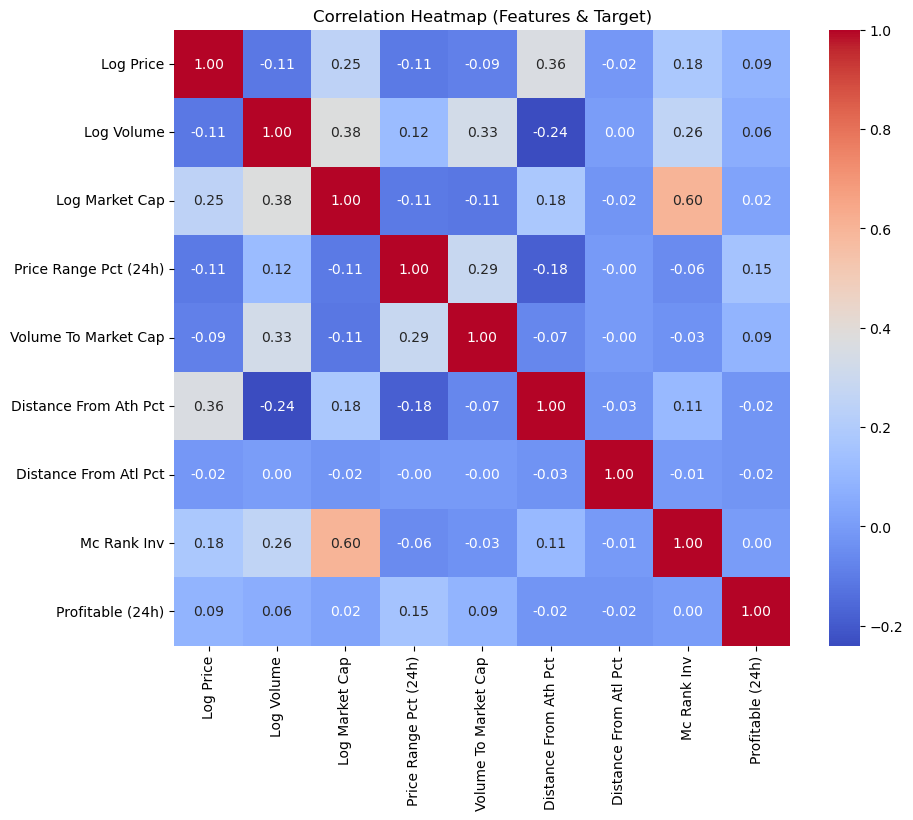

In [41]:
plt.figure(figsize=(10, 8))
corr = dff.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (Features & Target)')
plt.show()


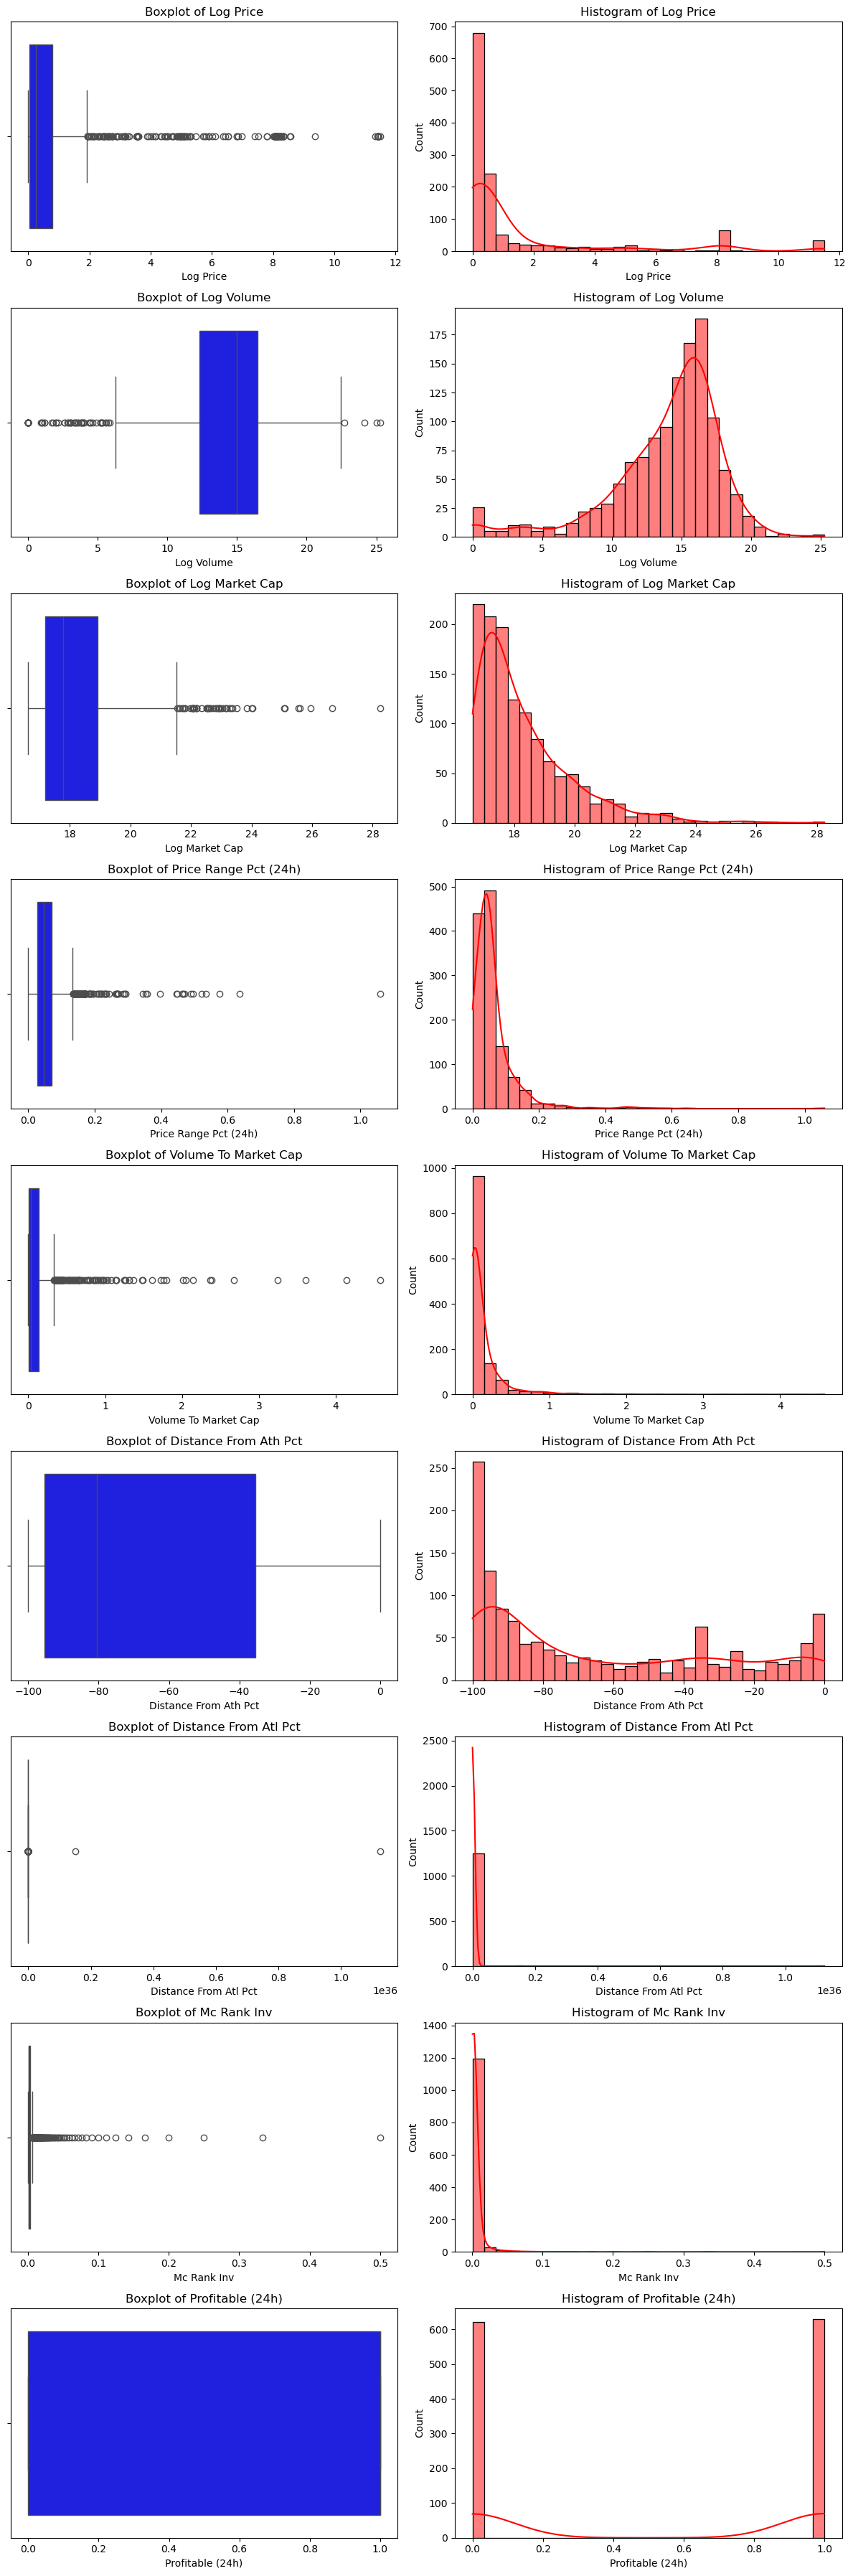

In [45]:
fig, axes = plt.subplots(len(dff.columns), 2, figsize=(12, 4 * len(dff.columns)))

for i, col in enumerate(dff.columns):
    sns.boxplot(x=df[col], ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Boxplot of {col}')
    sns.histplot(df[col], bins=30, ax=axes[i, 1], kde=True, color='red')
    axes[i, 1].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_23288\1129647761.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Profitable (0)', 'Profitable (1)'])


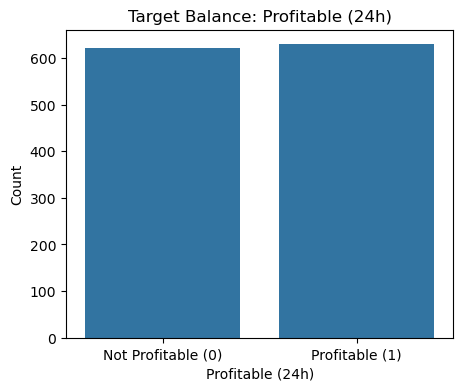

In [38]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=dff, x='Profitable (24h)')
ax.set_xticklabels(['Not Profitable (0)', 'Profitable (1)'])
plt.title('Target Balance: Profitable (24h)')
plt.xlabel('Profitable (24h)')
plt.ylabel('Count')
plt.show()

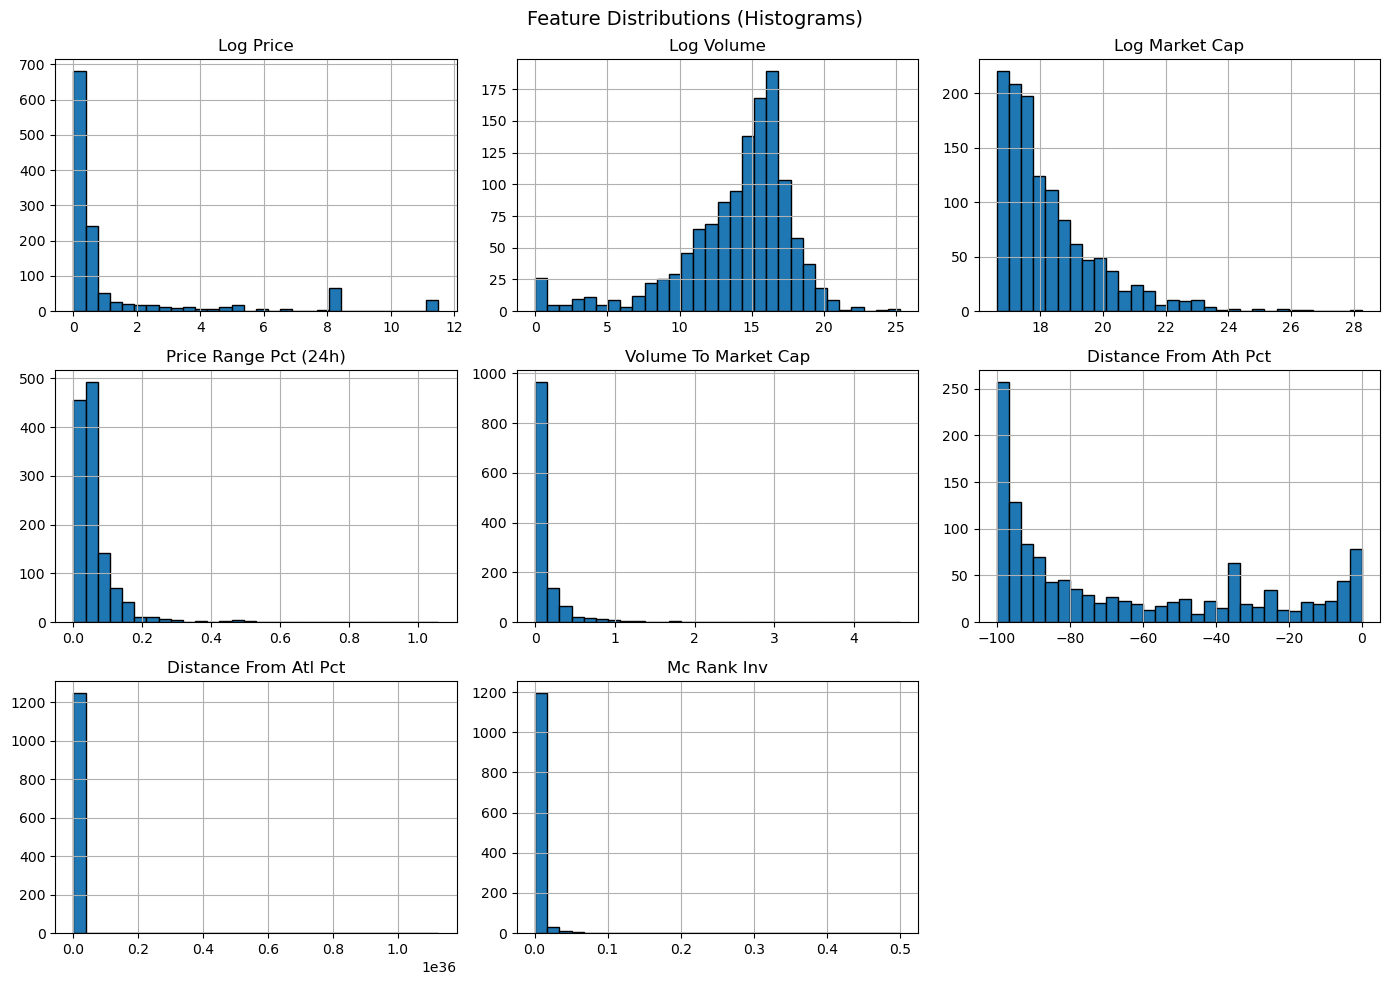

In [39]:
num_cols = [c for c in dff_cols if c != 'Profitable (24h)']
dff[num_cols].hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Feature Distributions (Histograms)', fontsize=14)
plt.tight_layout()
plt.show()

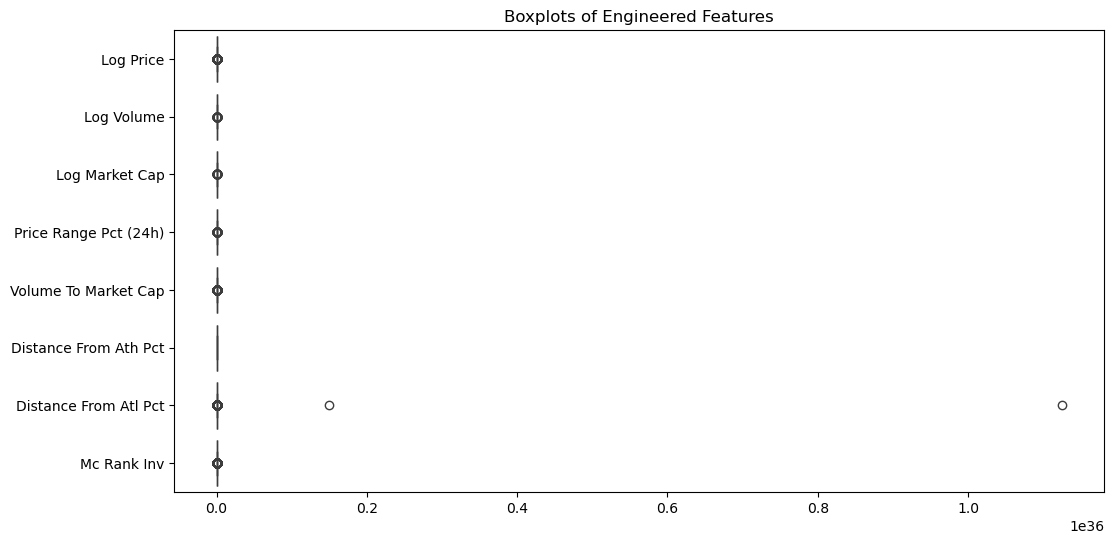

In [40]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=dff[num_cols], orient='h')
plt.title('Boxplots of Engineered Features')
plt.show()


#### Outliers Removing 

In [51]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25) 
    Q3 = data[column].quantile(0.75)  
    IQR = Q3 - Q1  
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

out_rem = remove_outliers_iqr(dff, 'Mc Rank Inv')
out_rem = remove_outliers_iqr(dff, 'Log Price')
out_rem = remove_outliers_iqr(dff, 'Distance From Atl Pct')
out_rem = remove_outliers_iqr(dff, 'Distance From Ath Pct')
out_rem = remove_outliers_iqr(dff, 'Volume To Market Cap')

#### Tetsing outliers removing

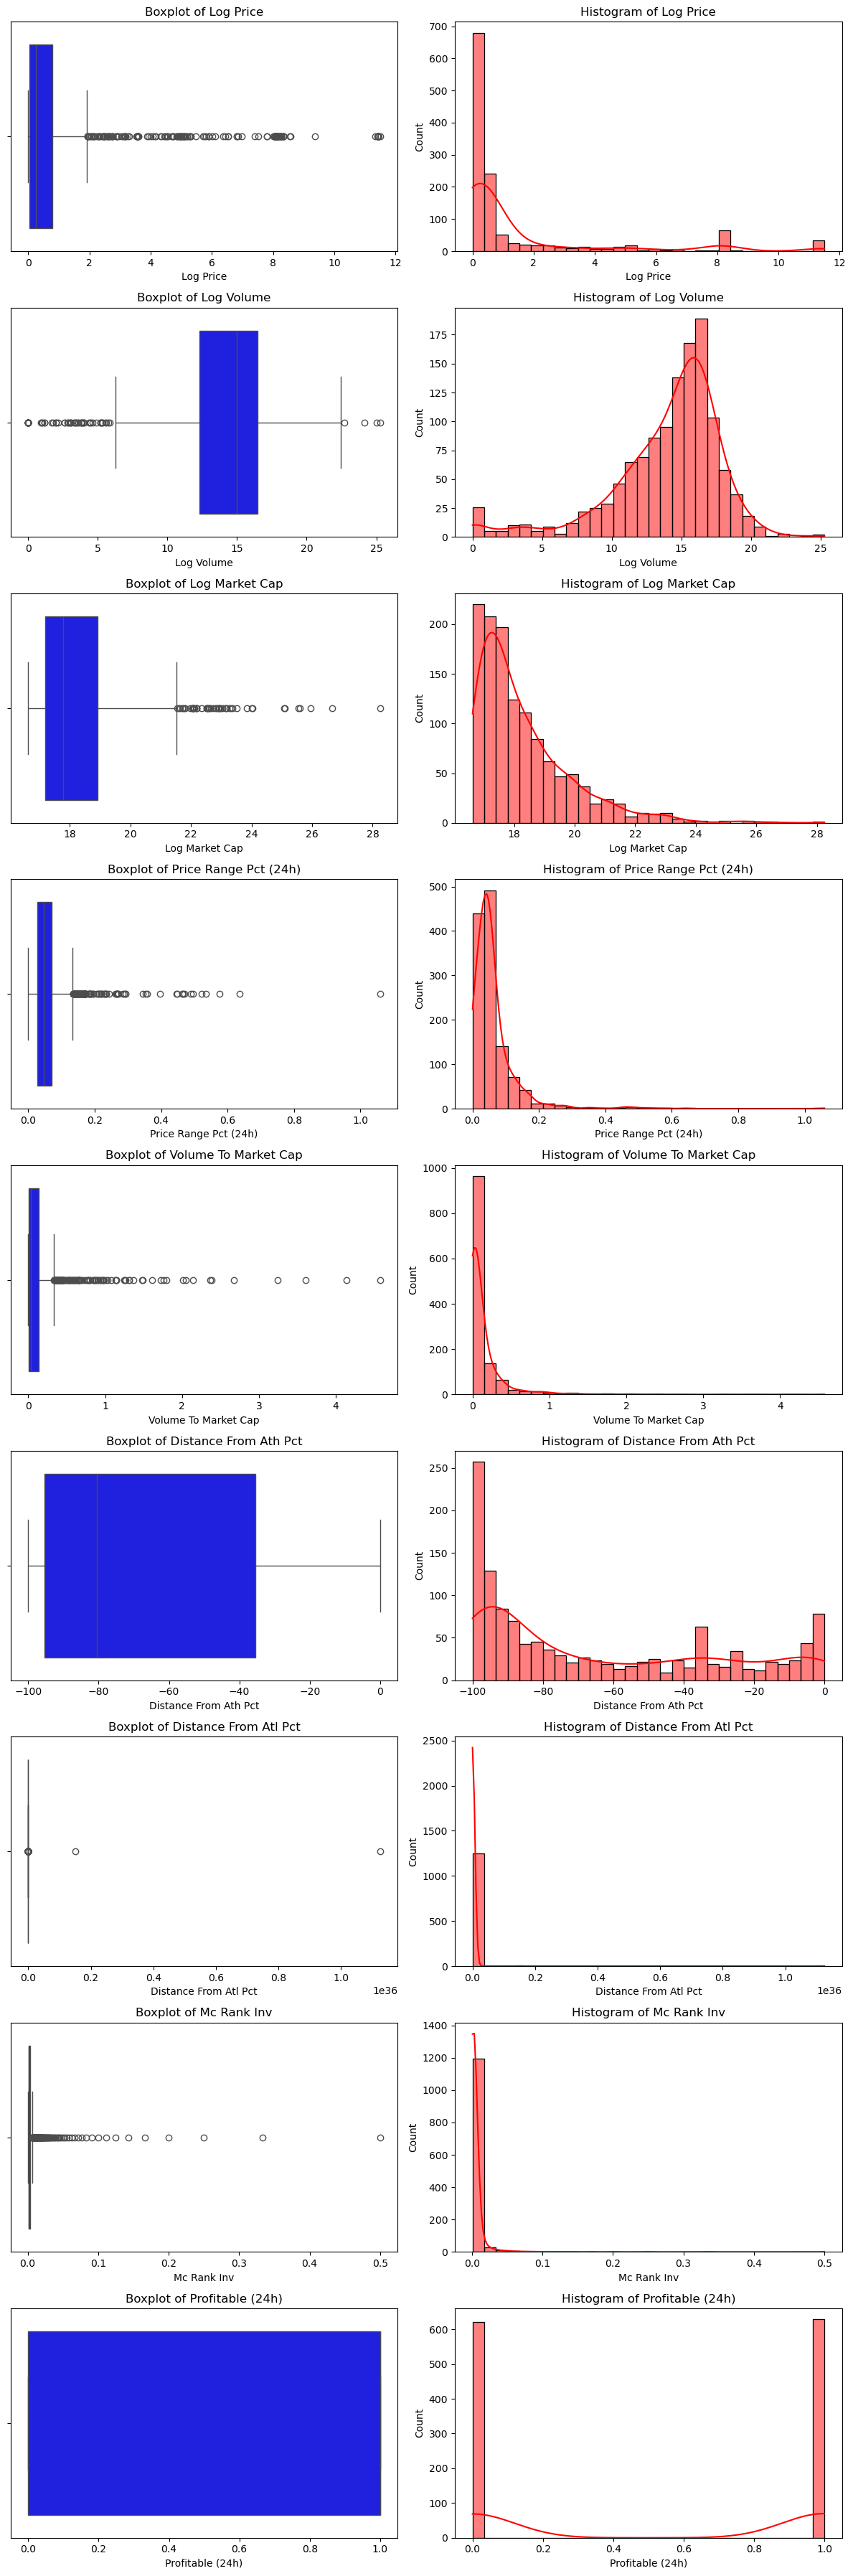

In [52]:
fig, axes = plt.subplots(len(dff.columns), 2, figsize=(12, 4 * len(dff.columns)))

for i, col in enumerate(dff.columns):
    sns.boxplot(x=df[col], ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Boxplot of {col}')
    sns.histplot(df[col], bins=30, ax=axes[i, 1], kde=True, color='red')
    axes[i, 1].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [54]:
out_rem.head(1)

,Log Price,Log Volume,Log Market Cap,Price Range Pct (24h),Volume To Market Cap,Distance From Ath Pct,Distance From Atl Pct,Mc Rank Inv,Profitable (24h)
0,11.436077,25.025981,28.245308,0.022062,0.039982,-26.25007,137026.07907,0.5,0


In [53]:
out_rem.to_csv("data_without_outliers.csv", index=False, encoding="utf-8-sig")

In [58]:
final= pd.DataFrame(out_rem)

### Model 

In [111]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_absolute_error,classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [68]:
y = final['Profitable (24h)']
x= final.drop(columns=['Profitable (24h)'])



In [69]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [70]:
Model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
Model.fit(X_train, y_train)

y_pred = Model.predict(X_test)

In [88]:
mae= mean_absolute_error(y_test,y_pred)
print(f"Mean Absolute Error: {mae}")
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score:  {accuracy*100:.2f}%")

Mean Absolute Error: 0.32142857142857145
Accuracy Score:  67.86%


#### Classification Report 

In [95]:
print(classification_report(y_test, y_pred, target_names=['Not Profitable (0)', 'Profitable (1)']))

                    precision    recall  f1-score   support

Not Profitable (0)       0.68      0.70      0.69       114
    Profitable (1)       0.68      0.65      0.67       110

          accuracy                           0.68       224
         macro avg       0.68      0.68      0.68       224
      weighted avg       0.68      0.68      0.68       224



#### ROC AUC Score

In [ ]:
y_pred_proba = Model.predict_proba(X_test)[:, 1]  
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")



ROC AUC Score: 0.7589


### Visualizing model


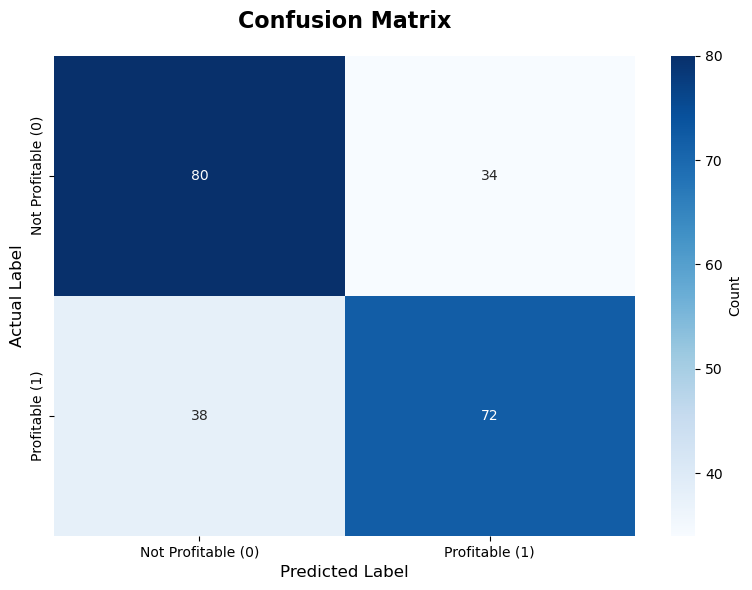

In [100]:
# 1. Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Profitable (0)', 'Profitable (1)'],
            yticklabels=['Not Profitable (0)', 'Profitable (1)'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


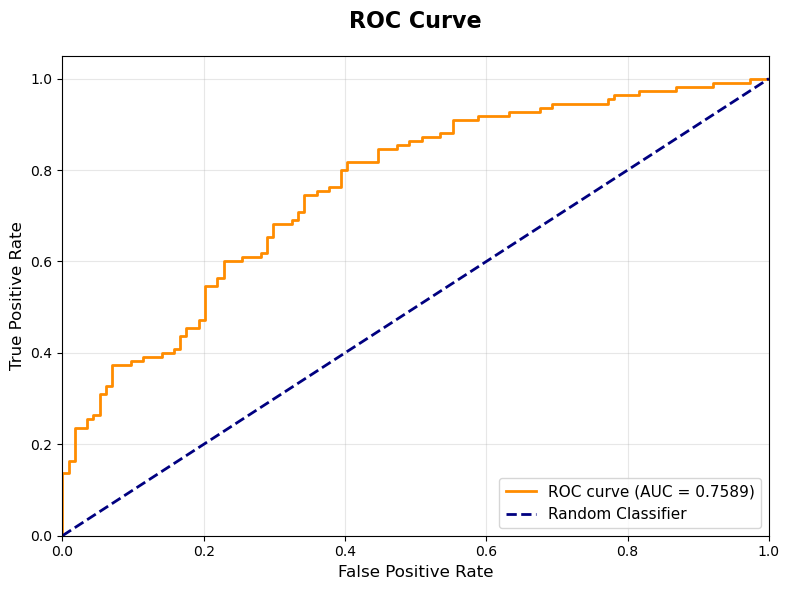

In [109]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_23288\3049527920.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


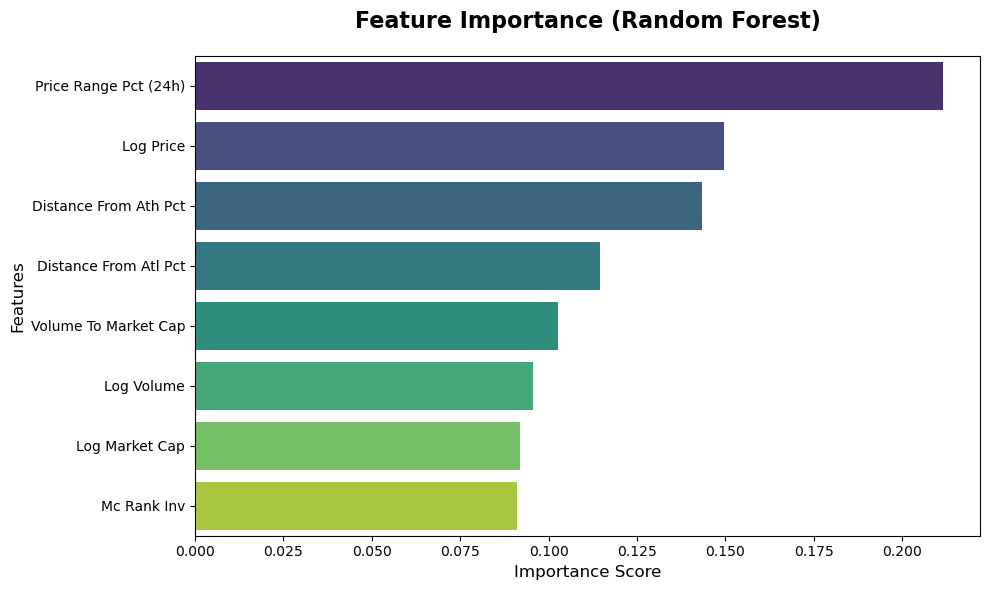


Feature Importance Rankings:
              feature  importance
Price Range Pct (24h)    0.211402
            Log Price    0.149613
Distance From Ath Pct    0.143426
Distance From Atl Pct    0.114521
 Volume To Market Cap    0.102606
           Log Volume    0.095615
       Log Market Cap    0.091822
          Mc Rank Inv    0.090995


In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': Model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance (Random Forest)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance.to_string(index=False))


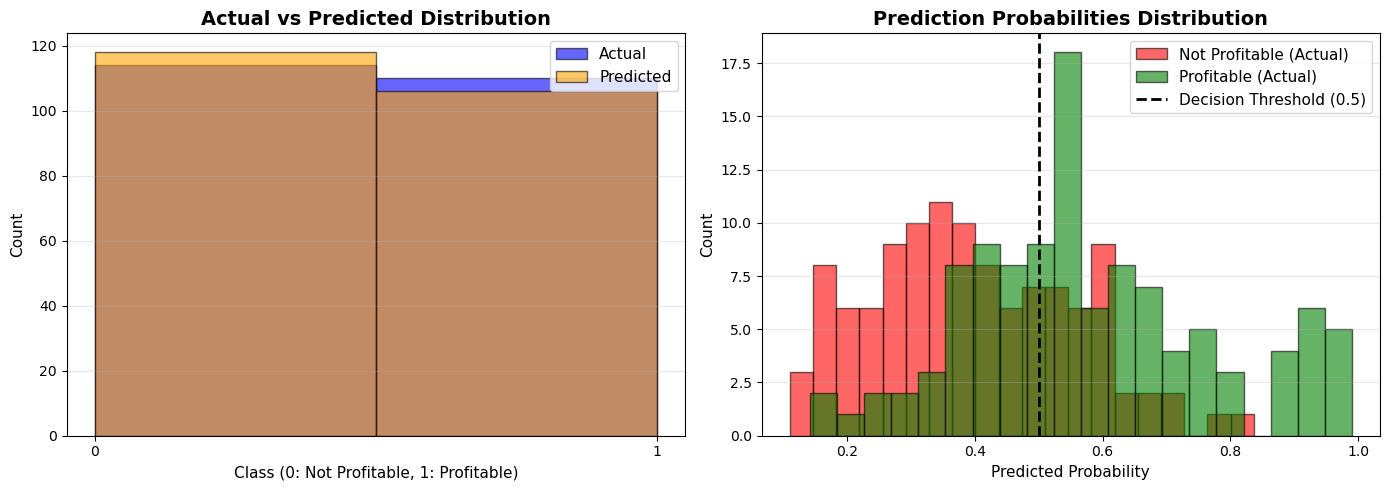

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                         # Actual vs Predicted Distribution
axes[0].hist(y_test, bins=2, alpha=0.6, label='Actual', color='blue', edgecolor='black')
axes[0].hist(y_pred, bins=2, alpha=0.6, label='Predicted', color='orange', edgecolor='black')
axes[0].set_xlabel('Class (0: Not Profitable, 1: Profitable)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Actual vs Predicted Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].set_xticks([0, 1])
axes[0].grid(axis='y', alpha=0.3)

                        # Prediction Probabilities Distribution
axes[1].hist(y_pred_proba[y_test == 0], bins=20, alpha=0.6, label='Not Profitable (Actual)', 
             color='red', edgecolor='black')
axes[1].hist(y_pred_proba[y_test == 1], bins=20, alpha=0.6, label='Profitable (Actual)', 
             color='green', edgecolor='black')
axes[1].set_xlabel('Predicted Probability', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Prediction Probabilities Distribution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [112]:
joblib.dump(Model, "Model.joblib")

['Model.joblib']